In [1]:
!pip install -q datasets
!pip install -q evaluate
!pip install -q accelerate -U
!pip install --upgrade transformers>=4.8.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 2.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.8.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12.5.82 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-nvrtc-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-nvrtc-cu12 12.5.82 which is incompatible.
t

In [2]:
import requests
import torch
from PIL import Image
from transformers import ViTImageProcessor, ViTForImageClassification, TrainingArguments
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


local = False

2025-07-21 17:23:02.942102: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753118583.139791      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753118583.194270      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


cuda


In [3]:
model_name = "google/vit-base-patch16-224"                        # the model name
model_name="google/vit-large-patch16-224-in21k"
model_name="google/vit-base-patch16-224-in21k"
image_processor = ViTImageProcessor.from_pretrained(model_name)   # load the image processor
model = ViTForImageClassification.from_pretrained(model_name)     # loading the pre-trained model

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224-in21k and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [4]:
train_dir = '/kaggle/input/knee-osteoarthritis-dataset-with-severity/train'
val_dir = '/kaggle/input/knee-osteoarthritis-dataset-with-severity/val'
test_dir = '/kaggle/input/knee-osteoarthritis-dataset-with-severity/test'
auto_test = '/kaggle/input/knee-osteoarthritis-dataset-with-severity/auto_test'
cat_dir = '/kaggle/input/cat-knee/clean'

In [5]:
import os

# ¿La carpeta raíz está ahí?
print(os.path.exists('/kaggle/input/knee-osteoarthritis-dataset-with-severity'))

True


In [6]:
print(os.listdir('/kaggle/input/knee-osteoarthritis-dataset-with-severity'))

['auto_test', 'val', 'test', 'train']


**Load Dataset**

In [7]:
from datasets import load_dataset

ds = load_dataset(
    "imagefolder",
    data_files={
        "train":      "/kaggle/input/knee-osteoarthritis-dataset-with-severity/train/*/*.png",
        "validation": "/kaggle/input/knee-osteoarthritis-dataset-with-severity/val/*/*.png",
        "test":       "/kaggle/input/knee-osteoarthritis-dataset-with-severity/test/*/*.png",
    },
)
print(ds)


Resolving data files:   0%|          | 0/5778 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/826 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1656 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 5778
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 826
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1656
    })
})


In [8]:
labels = ds["train"].features["label"]
labels

ClassLabel(names=['0', '1', '2', '3', '4'], id=None)

**Data Preprocessing**

In [9]:
def transform(examples):
  # convert all images to RGB format, then preprocessing it using our image processor
  inputs = image_processor([img.convert("RGB") for img in examples["image"]], return_tensors="pt")

  # we also shouldn't forget about the labels
  inputs["labels"] = examples["label"]

  return inputs

# use the with_transform() method to apply the transform to the dataset on the fly during training
dataset = ds.with_transform(transform)

In [10]:
import matplotlib.pyplot as plt
def show_image(dataset, split, index):
    data = dataset[split][index]
    if "image" in data:  # Original dataset
        image = data["image"]
        label = data["label"]

        plt.figure(figsize=(1, 1))
        plt.imshow(image)
        plt.axis('off')
        plt.title(f"Class {label}", fontsize=8)
        plt.show()
    else:  # Transformed dataset
        image_tensor = data['pixel_values']
        label = data['labels']

        # Convert the tensor to a NumPy array and display the image
        image_array = image_tensor.numpy()  # Convert the torch tensor to a NumPy array
        plt.figure(figsize=(1, 1))
        plt.imshow(image_array.transpose(1, 2, 0))  # Matplotlib expects the channel dimension last
        plt.title(f"Class {label}", fontsize=8)
        plt.axis('off')  # Hide the axis
        plt.show()

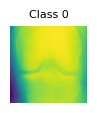

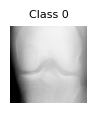

In [11]:
idx = 2
show_image(ds, "train", idx)
show_image(dataset, "train", idx)

In [12]:
for item in dataset["train"]:
  print(item["pixel_values"].shape)
  print(item["labels"])
  break

torch.Size([3, 224, 224])
0


In [13]:
labels = ds["train"].features["label"].names

def collate_fn(batch):
  return {
      "pixel_values": torch.stack([x["pixel_values"] for x in batch]),
      "labels": torch.tensor([x["labels"] for x in batch]),
  }

import datasets

cats_ds = load_dataset(
    cat_dir
)

cats_ds['validation'] = cats_ds['train']

cats_dataset = cats_ds.with_transform(transform)

from transformers import TrainerCallback, TrainerControl, TrainerState

class EvalExtraDatasetCallback(TrainerCallback):
    def __init__(self, extra_dataset, prefix="extra"):
        super().__init__()
        self.extra_dataset = extra_dataset
        self.prefix = prefix
        self.trainer = None  # se asignará en set_trainer()

    def on_train_begin(self, args, state: TrainerState, control: TrainerControl, **kwargs):
        # Capturamos aquí la instancia de Trainer
        print(f"Trainer {self.trainer}")

    def on_evaluate(self, args, state: TrainerState, control: TrainerControl, metrics=None, **kwargs):
        # Primero imprimimos las métricas estándar (ya hicieron print en Trainer)
        print(f"\n>>> Métricas estándar (@ step {state.global_step}): {metrics}")

        # Ahora evaluamos el dataset extra de gatos
        print(">>> Evaluando métrico del dataset de gatos...")
        extra_metrics = self.trainer.evaluate(eval_dataset=self.extra_dataset)

        # Renombramos las claves para distinguirlas
        #extra_metrics = {f"{self.prefix}_{k}": v for k, v in extra_metrics.items()}
        print(f"\n>>> Métricas [{self.prefix}]: {extra_metrics}")
        # Logueamos en TensorBoard / logger si usas report_to
        self.trainer.log(extra_metrics)

        # Y las mostramos por consola también
        

        return control

cats_cb = EvalExtraDatasetCallback(
    extra_dataset=cats_dataset,
    prefix="cats"
)


In [14]:
from evaluate import load
import numpy as np

# load the accuracy and f1 metrics from the evaluate module
accuracy = load("accuracy")
f1 = load("f1")

def compute_metrics(eval_pred):
  # compute the accuracy and f1 scores & return them
  accuracy_score = accuracy.compute(predictions=np.argmax(eval_pred.predictions, axis=1), references=eval_pred.label_ids)
  f1_score = f1.compute(predictions=np.argmax(eval_pred.predictions, axis=1), references=eval_pred.label_ids, average="macro")
  return {**accuracy_score, **f1_score}

In [15]:
!pip install GPUtil

import torch
from GPUtil import showUtilization as gpu_usage
from numba import cuda

def free_gpu_cache():
    print("Initial GPU Usage")
    gpu_usage()                             

    torch.cuda.empty_cache()

    cuda.select_device(0)
    cuda.close()
    cuda.select_device(0)

    print("GPU Usage after emptying the cache")
    gpu_usage()



  Preparing metadata (setup.py) ... done
  Created wheel for GPUtil: filename=GPUtil-1.4.0-py3-none-any.whl size=7392 sha256=453e5ef22d5b8c1cbba4eaa1f95c913bcafbffd2a5098e7787a270d4cac25060
  Stored in directory: /root/.cache/pip/wheels/2b/4d/8f/55fb4f7b9b591891e8d3f72977c4ec6c7763b39c19f0861595
Successfully built GPUtil


In [16]:
print({str(i): c for i, c in enumerate(labels)})

{'0': '0', '1': '1', '2': '2', '3': '3', '4': '4'}


In [17]:

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
def compute_metrics_regression(eval_pred):
    preds, labels = eval_pred
    # preds viene con forma (batch_size, 1)
    preds = preds.squeeze(-1)
    mse = mean_squared_error(labels, preds)
    mae = mean_absolute_error(labels, preds)
    return {
        "mse": mse,
        "rmse": np.sqrt(mse),
        "mae": mae,
    }

In [18]:
from transformers import (
    AutoModelForImageClassification,
    AutoImageProcessor,
    Trainer,
    EarlyStoppingCallback
)
import gc
from peft import PeftModel
from datasets import Value
model_name="google/vit-base-patch16-224"

regression = True

eval_steps = 50 if local else 250
save_steps = eval_steps

eval_sets = {
    "validation": dataset['validation'],   # tu validación habitual
  #  "cats": cats_dataset['validation'],          # tu split “extra”
}

training_args = TrainingArguments(
  output_dir="./vit-base-food", # output directory
  # output_dir="./vit-base-skin-cancer",
  per_device_train_batch_size=32, # batch size per device during training
  eval_strategy="steps",    # evaluation strategy to adopt during training
  num_train_epochs=8,             # total number of training epochs
  # fp16=True,                    # use mixed precision
  save_steps=save_steps,                # number of update steps before saving checkpoint
  eval_steps=eval_steps,                # number of update steps before evaluating
  logging_steps=eval_steps,             # number of update steps before logging
  # save_steps=50,
  # eval_steps=50,
  # logging_steps=50,
  metric_for_best_model="eval_validation_loss",  # coincide con la métrica real
  greater_is_better=False,
  save_total_limit=2,             # limit the total amount of checkpoints on disk
  remove_unused_columns=False,    # remove unused columns from the dataset
  push_to_hub=False,              # do not push the model to the hub
  report_to='tensorboard',        # report metrics to tensorboard
  load_best_model_at_end=True,    # load the best model at the end of training
  learning_rate=1e-4
)




image_processor = AutoImageProcessor.from_pretrained(
    model_name,
    size={"height": 224, "width": 224},
    use_fast=True
)

try:
    # Carga el modelo para clasificación de imágenes

    if regression:
        dataset_reg = dataset.cast_column("label", Value("float32"))
        
        model = AutoModelForImageClassification.from_pretrained(
            model_name,
            num_labels=1,
            problem_type="regression",
            ignore_mismatched_sizes=True,
        )

        # Creamos el Trainer genérico
        trainer = Trainer(
            model=model,
            args=training_args,                 # tus TrainingArguments
            data_collator=collate_fn,           # tu función de batching
            compute_metrics=compute_metrics_regression,    # tu función de métricas
            train_dataset=dataset_reg["train"],
            eval_dataset=eval_sets,
            tokenizer=image_processor,          # usamos el image_processor como "tokenizer"
            callbacks=[]
        )
    else:
        model = AutoModelForImageClassification.from_pretrained(
            model_name,
            num_labels=len(labels),
            id2label={str(i): c for i, c in enumerate(labels)},
            label2id={c: str(i) for i, c in enumerate(labels)},
            ignore_mismatched_sizes=True,
        )
    
        # Creamos el Trainer genérico
        trainer = Trainer(
            model=model,
            args=training_args,                 # tus TrainingArguments
            data_collator=collate_fn,           # tu función de batching
            compute_metrics=compute_metrics,    # tu función de métricas
            train_dataset=dataset["train"],
            eval_dataset=eval_sets,
            tokenizer=image_processor,          # usamos el image_processor como "tokenizer"
            callbacks=[]
        )
    #trainer.add_callback(cats_cb)  # registra el callback
    #cats_cb.trainer = trainer  

    # Entrenamos
    trainer.train()
except Exception as e:
    print(f"Error {e}")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Casting the dataset:   0%|          | 0/5778 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/826 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1656 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([1]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([1, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_19/837830050.py:68: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss,Validation Loss,Validation Mse,Validation Rmse,Validation Mae
250,0.741800,0.566223,0.566223,0.752478,0.589832
500,0.386600,0.464370,0.464370,0.681447,0.511654
750,0.219400,0.484349,0.484349,0.695952,0.532077
1000,0.107400,0.503291,0.503291,0.709430,0.505200
1250,0.055600,0.506665,0.506665,0.711804,0.509784


from transformers import (
    AutoConfig,
    AutoModelForImageClassification,
    AutoImageProcessor,
    TrainingArguments,
    Trainer
)
from peft import PeftModel
import torch
import gc

# 1. NOMBRE DE MODELOS
base_model_name   = "google/vit-base-patch16-224-in21k"
lora_adapter_name = "neuralhaven/vit-large-patch16-224-in21k-finetuned-lora-medmnistv2"

# 2. LISTA REAL DE ETIQUETAS (¡sin ellipsis!)
# Si usas 🤗Datasets:
labels = dataset["train"].features["label"].names
# O manualmente:
# labels = ["normal", "adenoma", "carcinoma", "melanoma", "nevus"]

# 3. Procesador de imágenes
image_processor = AutoImageProcessor.from_pretrained(
    base_model_name,
    size={"height": 224, "width": 224},
    use_fast=True
)

# 4. Configuración con el número correcto de clases
config = AutoConfig.from_pretrained(
    base_model_name,
    num_labels=len(labels),
    id2label={str(i): lbl for i, lbl in enumerate(labels)},
    label2id={lbl: i      for i, lbl in enumerate(labels)}
)

# 5. Carga del modelo base (reemplaza la cabeza automáticamente)
base_model = AutoModelForImageClassification.from_pretrained(
    base_model_name,
    config=config,
    ignore_mismatched_sizes=True
)

# 6. Inyecta el adaptador LoRA sobre el modelo base
model = PeftModel.from_pretrained(
    base_model,
    lora_adapter_name
)


# 8. Argumentos de entrenamiento
local = False
eval_steps = 50 if local else 250

training_args = TrainingArguments(
    output_dir="./vit-large-medmnist",
    per_device_train_batch_size=32,
    num_train_epochs=8,
    eval_strategy="steps",
    save_steps=eval_steps,
    eval_steps=eval_steps,
    logging_steps=eval_steps,
    metric_for_best_model="eval_validation_loss",
    greater_is_better=False,
    save_total_limit=2,
    remove_unused_columns=False,
    push_to_hub=False,
    report_to="tensorboard",
    load_best_model_at_end=True,
    learning_rate=1e-4
)

# 9. Conjuntos de evaluación
eval_sets = {
    "validation": dataset["validation"],
    "cats":       cats_dataset["validation"]
}

# 10. Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    train_dataset=dataset["train"],
    eval_dataset=eval_sets,
    tokenizer=image_processor,
    callbacks=[]
)

# 11. Entrenamiento
gc.collect()
trainer.train()


In [19]:
trainer.evaluate(dataset["test"])

{'eval_loss': 0.4388554096221924,
 'eval_mse': 0.43885543447639636,
 'eval_rmse': 0.6624616475513102,
 'eval_mae': 0.49728001778078396,
 'eval_runtime': 21.4162,
 'eval_samples_per_second': 77.325,
 'eval_steps_per_second': 9.666,
 'epoch': 8.0}

**Evaluation with Confusion Matrix**

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_matriz_confusion(trainer, dataset_val, label_names):
    # 1) Predice sobre el dataset de validación
    outputs = trainer.predict(dataset_val)
    y_true = outputs.label_ids
    y_pred = outputs.predictions.argmax(axis=1)

    # 2) Calcula la matriz de confusión
    cm = confusion_matrix(y_true, y_pred)

    # 3) La dibuja con etiquetas
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=label_names)
    disp.plot(xticks_rotation=45)
    plt.show()

# Suponiendo que labels = ['bajo', 'medio', 'alto'] o como tú las llames:
if not regression:
    label_names = dataset["train"].features["label"].names
    plot_matriz_confusion(trainer, dataset["validation"], label_names)


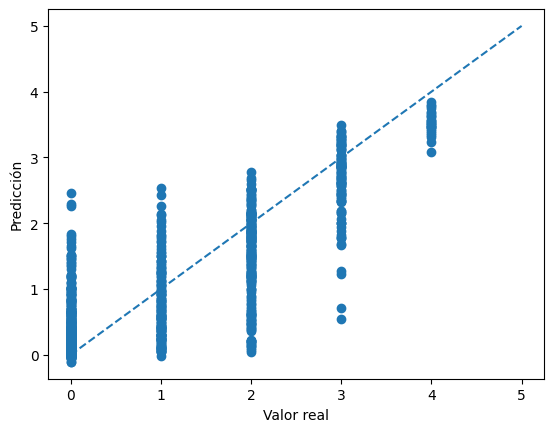

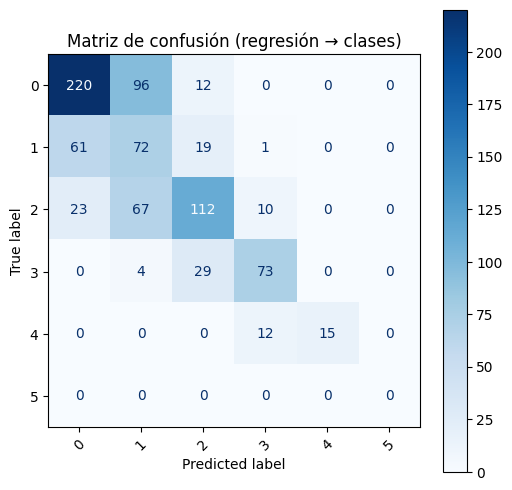

In [21]:
import matplotlib.pyplot as plt

def plot_regression_scatter(trainer, dataset_val):
    outputs = trainer.predict(dataset_val)
    y_true = outputs.label_ids
    y_pred = outputs.predictions.squeeze(-1)
    plt.scatter(y_true, y_pred)
    plt.plot([0,5],[0,5], linestyle='--')  # línea de identidad
    plt.xlabel("Valor real")
    plt.ylabel("Predicción")
    plt.show()

if regression:
    plot_regression_scatter(trainer, dataset["validation"])

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

def plot_regression_confusion(trainer, dataset_val, num_classes=6):
    # 1) Predicción del Trainer
    outputs = trainer.predict(dataset_val)
    y_true = outputs.label_ids            # deberían ser enteros 0–5 o floats sin decimales
    y_pred = outputs.predictions.squeeze(-1)  # valores continuos

    # 2) Convierte a clases redondeando y limitando al rango [0, num_classes-1]
    y_pred_cls = np.rint(y_pred).astype(int)
    y_pred_cls = np.clip(y_pred_cls, 0, num_classes-1)

    # 3) Matriz de confusión
    cm = confusion_matrix(y_true, y_pred_cls, labels=np.arange(num_classes))

    # 4) Dibujar
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[str(i) for i in range(num_classes)]
    )
    fig, ax = plt.subplots(figsize=(6,6))
    disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation=45)
    ax.set_title("Matriz de confusión (regresión → clases)")
    plt.show()

# Y al final:
if regression:
    plot_regression_confusion(trainer, dataset["validation"])


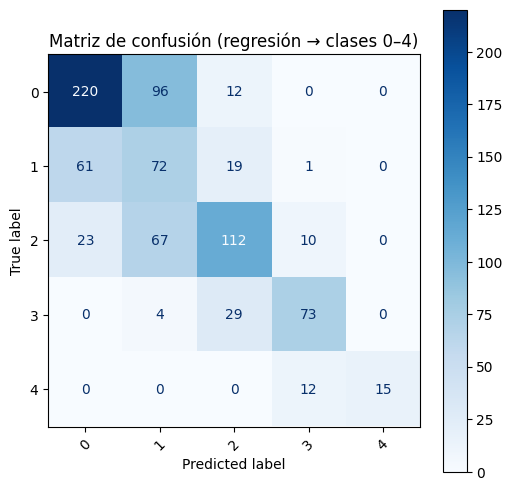

,precision,recall,f1-score,support
clase_0,0.723684,0.670732,0.696203,328
clase_1,0.301255,0.470588,0.367347,153
clase_2,0.651163,0.528302,0.583333,212
clase_3,0.760417,0.688679,0.722772,106
clase_4,1.000000,0.555556,0.714286,27



📊 Métricas macro‑promedio:
  • Precision media: 0.687
  • Recall medio:    0.583
  • F1‑score medio:  0.617



In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support
)

def plot_regression_confusion_and_metrics(trainer, dataset_val):
    # 1) Predecir
    outputs = trainer.predict(dataset_val)
    y_true = outputs.label_ids
    y_pred_cont = outputs.predictions.squeeze(-1)

    # 2) Rango dinámico según datos reales
    min_real = int(np.min(y_true))
    max_real = int(np.max(y_true))
    clases = np.arange(min_real, max_real+1)

    # 3) Discretizar + clip
    y_pred = np.rint(y_pred_cont).astype(int)
    y_pred = np.clip(y_pred, min_real, max_real)

    # 4) Matriz de confusión
    cm = confusion_matrix(y_true, y_pred, labels=clases)
    disp = ConfusionMatrixDisplay(cm, display_labels=clases)
    fig, ax = plt.subplots(figsize=(6,6))
    disp.plot(ax=ax, cmap=plt.cm.Blues, xticks_rotation=45)
    ax.set_title(f"Matriz de confusión (regresión → clases {min_real}–{max_real})")
    plt.show()

    # 5) Métricas por clase
    precision, recall, f1_score, support = precision_recall_fscore_support(
        y_true, y_pred,
        labels=clases,
        average=None,
        zero_division=0
    )

    df_metrics = pd.DataFrame({
        "precision": precision,
        "recall":    recall,
        "f1-score":  f1_score,
        "support":   support
    }, index=[f"clase_{c}" for c in clases])

    display(df_metrics)

    # 6) Cálculo de macro‑promedios
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred,
        labels=clases,
        average="macro",
        zero_division=0
    )

    print(f"\n📊 Métricas macro‑promedio:")
    print(f"  • Precision media: {precision_macro:.3f}")
    print(f"  • Recall medio:    {recall_macro:.3f}")
    print(f"  • F1‑score medio:  {f1_macro:.3f}\n")

# Uso:
if regression:
    plot_regression_confusion_and_metrics(trainer, dataset["validation"])


In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_matrix_confussion(trainer, dataset_val):
    outputs = trainer.predict(dataset_val)
    y_true = outputs.label_ids
    y_pred = outputs.predictions.argmax(1)
    
    labels = dataset["train"].features['label'].names
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(xticks_rotation=45)

if not regression:
    plot_matrix_confussion(trainer, dataset['val'])

**Generate Precision, Recall, F1 Score, Support**

**Generate Training & Loss Curves**

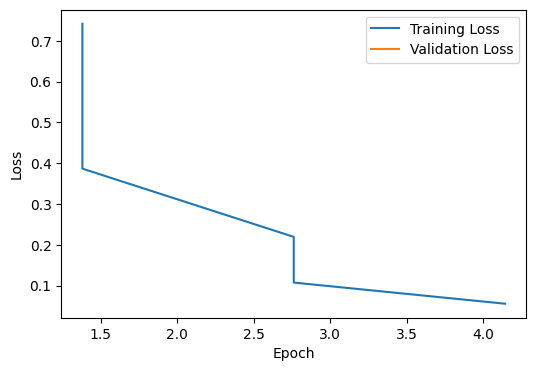

In [24]:
import matplotlib.pyplot as plt

data = trainer.state.log_history
# Extracting data for plotting
epochs = [entry['epoch'] for entry in data]  # Extract epoch values
train_losses = [entry['loss'] for entry in data if 'loss' in entry]  # Extract training losses
eval_losses = [entry['eval_loss'] for entry in data if 'eval_loss' in entry]  # Extract evaluation losses

# Plotting training and evaluation metrics
plt.figure(figsize=(6, 4))

plt.plot(epochs[:len(train_losses)], train_losses, label='Training Loss')
plt.plot(epochs[:len(eval_losses)], eval_losses, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
# plt.title('Training and Evaluation Metrics Across Epochs')
plt.legend()
# plt.grid(True)
plt.show()

**Plot ROC Curves**

In [25]:
from scipy.special import softmax
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc_multiclass(trainer, dataset_val):
    # 1) Predecir
    outputs = trainer.predict(dataset_val)
    logits = outputs.predictions
    y_true = outputs.label_ids

    # 2) Logits → probabilidades
    probs = softmax(logits, axis=1)

    # 3) Cálculo FPR, TPR, AUC
    num_classes = probs.shape[1]
    fpr = {}
    tpr = {}
    roc_auc = {}
    for i in range(num_classes):
        y_bin = (y_true == i).astype(int)
        fpr[i], tpr[i], _ = roc_curve(y_bin, probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # 4) Ploteo
    plt.figure(figsize=(6, 4))
    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i], lw=2,
                 label=f"Clase {i} (AUC = {roc_auc[i]:.3f})")
    plt.plot([0,1], [0,1], "--", lw=1, color="gray")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Curvas ROC multiclas")
    plt.legend(loc="lower right")
    plt.show()

# Uso sólo en clasificación
if not regression:
    plot_roc_multiclass(trainer, dataset["validation"])


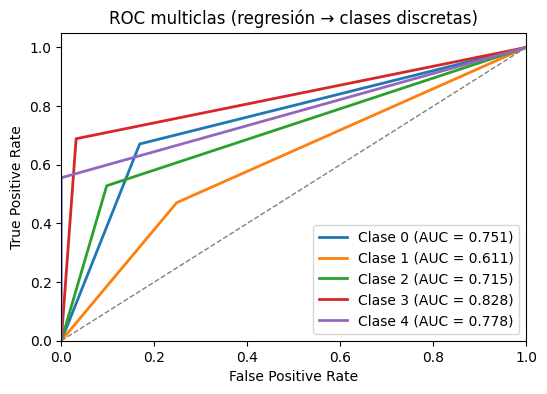

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

def plot_regression_roc(trainer, dataset_val):
    # 1) Predecir
    outputs = trainer.predict(dataset_val)
    y_true = outputs.label_ids
    y_pred_cont = outputs.predictions.squeeze(-1)

    # 2) Rango dinámico según datos reales
    min_real = int(np.min(y_true))
    max_real = int(np.max(y_true))
    clases = np.arange(min_real, max_real+1)
    num_classes = len(clases)

    # 3) Discretizar + clip
    y_pred_cls = np.rint(y_pred_cont).astype(int)
    y_pred_cls = np.clip(y_pred_cls, min_real, max_real)

    # 4) Construir “probabilidades” one‑hot a partir de la clase predicha
    #    (1 para la clase elegida, 0 para el resto)
    probs = np.zeros((len(y_pred_cls), num_classes))
    for idx, c in enumerate(clases):
        probs[:, idx] = (y_pred_cls == c).astype(int)

    # 5) Calcular FPR, TPR y AUC para cada clase
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for idx, c in enumerate(clases):
        y_bin = (y_true == c).astype(int)
        fpr[idx], tpr[idx], _ = roc_curve(y_bin, probs[:, idx])
        roc_auc[idx] = auc(fpr[idx], tpr[idx])

    # 6) Dibujar todas las curvas en un mismo gráfico
    plt.figure(figsize=(6, 4))
    for idx, c in enumerate(clases):
        plt.plot(fpr[idx], tpr[idx], lw=2,
                 label=f"Clase {c} (AUC = {roc_auc[idx]:.3f})")

    # Línea de azar
    plt.plot([0, 1], [0, 1], "--", lw=1, color="gray")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC multiclas (regresión → clases discretas)")
    plt.legend(loc="lower right")
    plt.show()

# Para usarla:
if regression:
    plot_regression_roc(trainer, dataset["validation"])
